In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv(r'C:\Users\sumit\OneDrive\Desktop\Iris flower\IRIS_cleaned.csv')

#Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

#Remove duplicates
df = df.drop_duplicates()

#Check for missing values and fill with median if necessary
for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

#Clean text column (species)
if 'species' in df.columns:
    df['species'] = df['species'].astype(str).str.strip().str.lower()

#Verify column names and data types
print("✅ Cleaned column names:", list(df.columns))
print("\n✅ Data summary:\n", df.describe(include='all'))

#Save the cleaned dataset
df.to_csv(r'C:\Users\sumit\OneDrive\Desktop\Iris flower\IRIS_cleaned.csv', index=False)
print("\n✅ Cleaned dataset saved successfully as 'IRIS_cleaned.csv' in your notebook folder!")

#Show sample
df.head()

✅ Cleaned column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

✅ Data summary:
         sepal_length  sepal_width  petal_length  petal_width          species
count     147.000000   147.000000    147.000000   147.000000              147
unique           NaN          NaN           NaN          NaN                3
top              NaN          NaN           NaN          NaN  iris-versicolor
freq             NaN          NaN           NaN          NaN               50
mean        5.856463     3.055782      3.780272     1.208844              NaN
std         0.829100     0.437009      1.759111     0.757874              NaN
min         4.300000     2.000000      1.000000     0.100000              NaN
25%         5.100000     2.800000      1.600000     0.300000              NaN
50%         5.800000     3.000000      4.400000     1.300000              NaN
75%         6.400000     3.300000      5.100000     1.800000              NaN
max         7.900000     4

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,iris-setosa
1,4.9,3.0,1.4,0.2,iris-setosa
2,4.7,3.2,1.3,0.2,iris-setosa
3,4.6,3.1,1.5,0.2,iris-setosa
4,5.0,3.6,1.4,0.2,iris-setosa


In [7]:
print("Shape:", df.shape)
print(df.columns)
display(df.head())
display(df.describe(include='all'))
print("Missing values:\n", df.isnull().sum())

Shape: (147, 5)
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,iris-setosa
1,4.9,3.0,1.4,0.2,iris-setosa
2,4.7,3.2,1.3,0.2,iris-setosa
3,4.6,3.1,1.5,0.2,iris-setosa
4,5.0,3.6,1.4,0.2,iris-setosa


,sepal_length,sepal_width,petal_length,petal_width,species
count,147.000000,147.000000,147.000000,147.000000,147
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,iris-versicolor
freq,NaN,NaN,NaN,NaN,50
mean,5.856463,3.055782,3.780272,1.208844,NaN
std,0.829100,0.437009,1.759111,0.757874,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.400000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


Missing values:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [8]:
# Standardize column names to safe, lowercase names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


In [9]:
# Ensure numeric columns are numeric
num_cols = ['sepal_length','sepal_width','petal_length','petal_width']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Check for nulls again
print(df[num_cols].isnull().sum())

# If any nulls appear, fill with median (simple, safe)
for c in num_cols:
    if df[c].isnull().sum() > 0:
        df[c].fillna(df[c].median(), inplace=True)

# Normalize species text
df['species'] = df['species'].astype(str).str.strip().str.lower()
print(df['species'].value_counts())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
dtype: int64
species
iris-versicolor    50
iris-virginica     49
iris-setosa        48
Name: count, dtype: int64


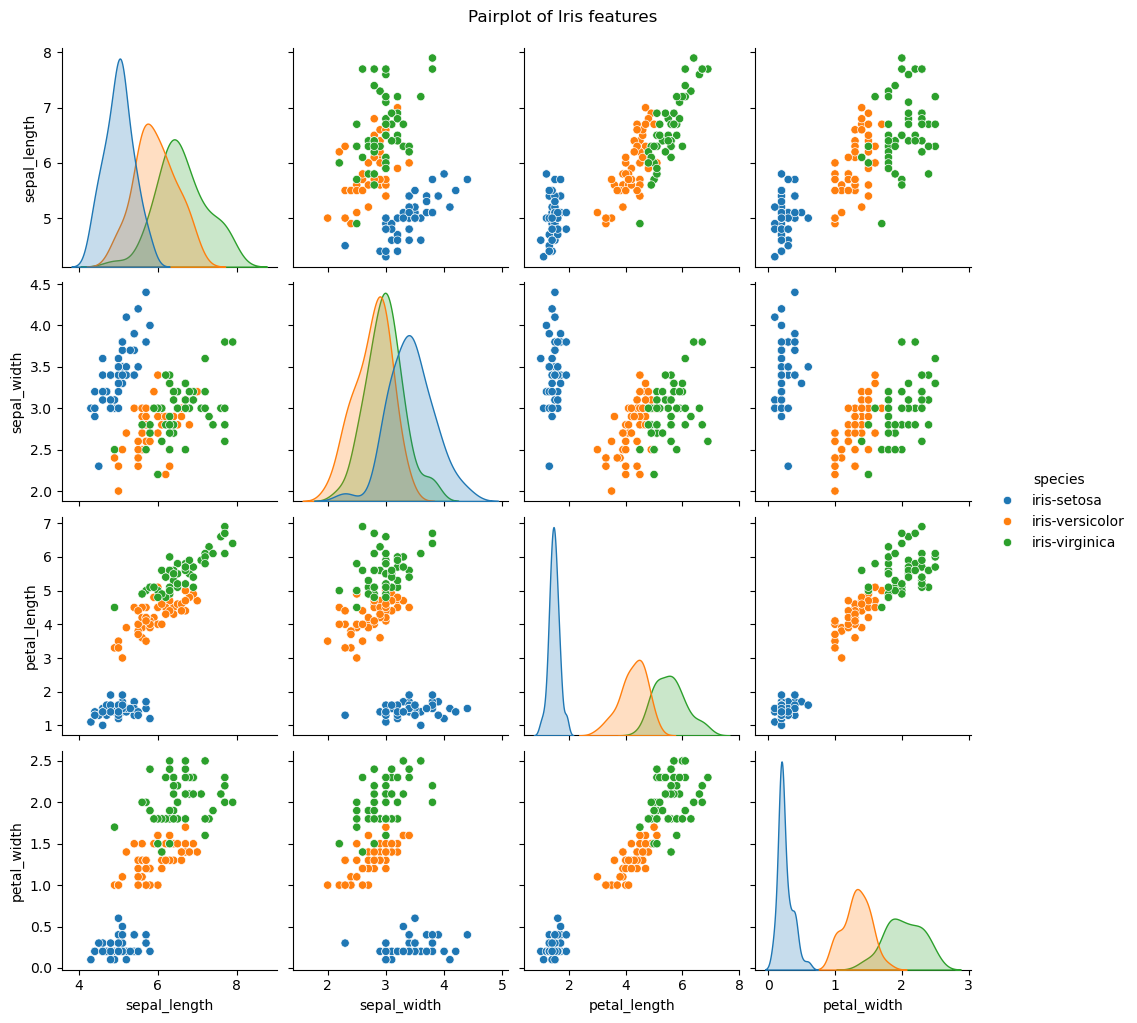

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pairplot (scatterplots + histograms) by species
sns.pairplot(df, hue='species', vars=num_cols)
plt.suptitle('Pairplot of Iris features', y=1.02)
plt.show()

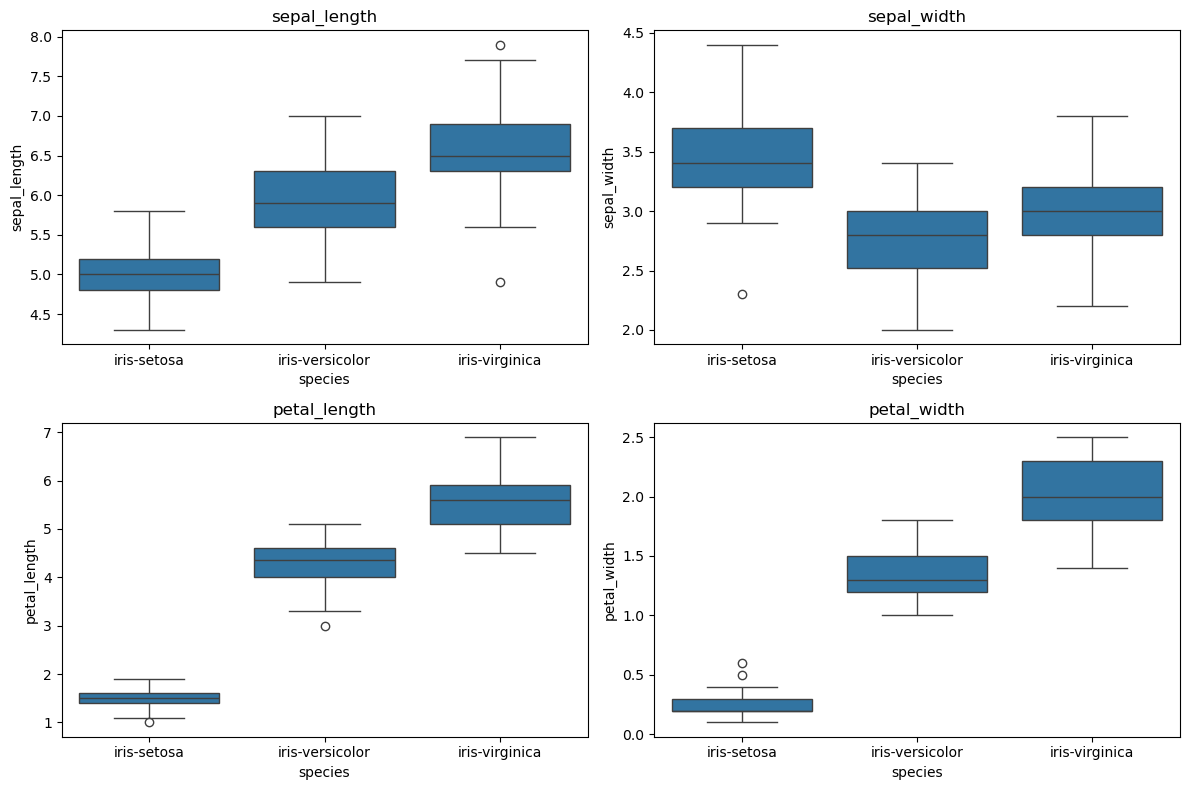

In [11]:
# Boxplots for each measurement grouped by species
plt.figure(figsize=(12,8))
for i,c in enumerate(num_cols,1):
    plt.subplot(2,2,i)
    sns.boxplot(x='species', y=c, data=df)
    plt.title(c)
plt.tight_layout()
plt.show()

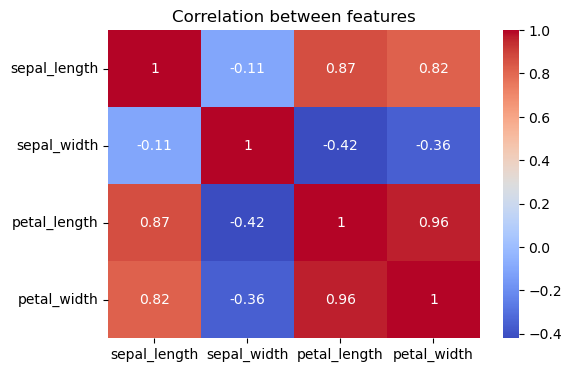

In [12]:
# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between features')
plt.show()


Data Split Done ✅
Training samples: 117
Testing samples: 30
Accuracy: 0.9333333333333333
                 precision    recall  f1-score   support

    iris-setosa       1.00      1.00      1.00        11
iris-versicolor       0.90      0.90      0.90        10
 iris-virginica       0.89      0.89      0.89         9

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



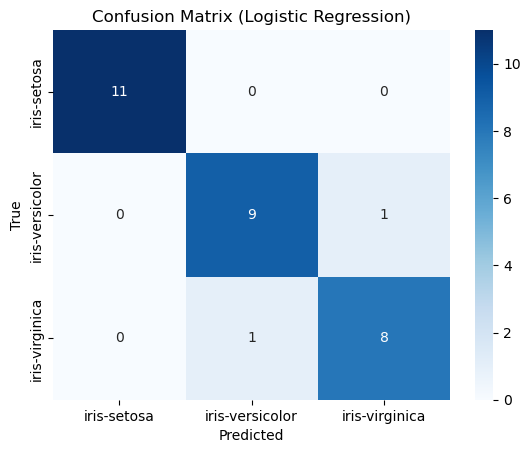

In [18]:
# Step 5: Prepare Data
X = df.drop("species", axis=1)   # features
y = df["species"]               # target

# Encode target labels
le = LabelEncoder()
y = le.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nData Split Done ✅")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# Step 6: Train a Logistic Regression Model
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

# Step 7: Make Predictions
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix (Logistic Regression)')
plt.show()

RF Accuracy: 0.9333333333333333
                 precision    recall  f1-score   support

    iris-setosa       1.00      1.00      1.00        11
iris-versicolor       0.90      0.90      0.90        10
 iris-virginica       0.89      0.89      0.89         9

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

Feature importances:
 petal_length    0.478000
petal_width     0.383956
sepal_length    0.107516
sepal_width     0.030529
dtype: float64


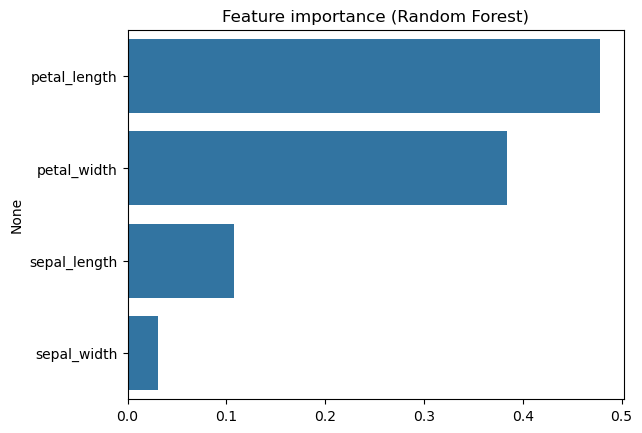

In [19]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# Feature importances
importances = pd.Series(rf.feature_importances_, index=num_cols).sort_values(ascending=False)
print("Feature importances:\n", importances)
sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature importance (Random Forest)')
plt.show()

In [23]:
# Cross-validation using Random Forest
scores = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42), 
                         X, y, cv=5)

print("Cross-val accuracy (5-fold):", scores)
print("Mean cross-val accuracy:", scores.mean())

Cross-val accuracy (5-fold): [0.96666667 0.96666667 0.93103448 0.93103448 1.        ]
Mean cross-val accuracy: 0.9590804597701149


In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.9333
Random Forest Accuracy: 0.9333


In [32]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Example: predict species for a new flower
example = [[5.1, 3.5, 1.4, 0.2]]  # sepal_length, sepal_width, petal_length, petal_width
pred_label = rf.predict(example)
print("Predicted encoded label:", pred_label)
print("Predicted species:", (pred_label))